In [3]:
%pip install datasets pyttsx3 seaborn tensorflow scikit-learn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import string


from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical

import pyttsx3


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\raviv\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [4]:
# -----------------------------
# 1. Load Dataset
# -----------------------------
train_df = pd.read_csv("data/sign_mnist_train.csv")
test_df = pd.read_csv("data/sign_mnist_test.csv")

X_train = train_df.drop("label", axis=1)
y_train = train_df["label"]

X_test = test_df.drop("label", axis=1)
y_test = test_df["label"]


In [5]:
# -----------------------------
# 2. Basic Dataset Information
# -----------------------------
print("\nDataset Info:")
print(train_df.info())

print("\nMissing Values Check:")
print(train_df.isnull().sum().sum())


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27455 entries, 0 to 27454
Columns: 785 entries, label to pixel784
dtypes: int64(785)
memory usage: 164.4 MB
None

Missing Values Check:
0



Class Distribution (Training Set):
label
0     1126
1     1010
2     1144
3     1196
4      957
5     1204
6     1090
7     1013
8     1162
10    1114
11    1241
12    1055
13    1151
14    1196
15    1088
16    1279
17    1294
18    1199
19    1186
20    1161
21    1082
22    1225
23    1164
24    1118
Name: count, dtype: int64


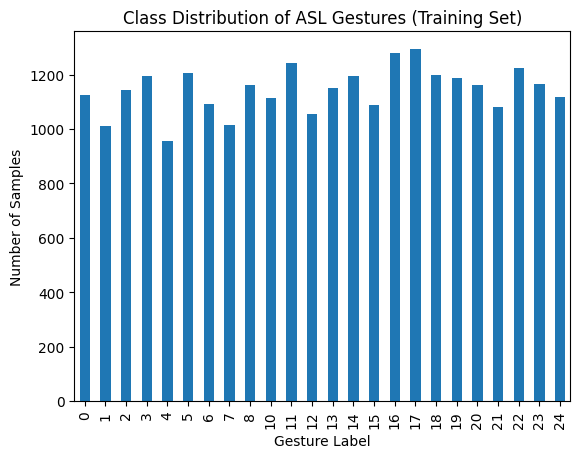

In [6]:
# -----------------------------
# 3. Class Distribution Analysis
# -----------------------------
label_counts = train_df['label'].value_counts().sort_index()

print("\nClass Distribution (Training Set):")
print(label_counts)

plt.figure()
label_counts.plot(kind='bar')
plt.title("Class Distribution of ASL Gestures (Training Set)")
plt.xlabel("Gesture Label")
plt.ylabel("Number of Samples")
plt.show()

The figure shows that all gesture classes contain approximately 1,000 to 1,300 samples, indicating a relatively balanced dataset. No significant class imbalance is observed, as sample counts across labels remain consistent.

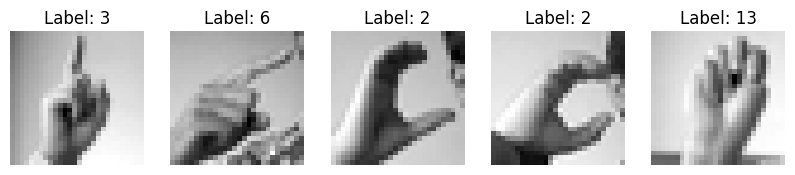

In [7]:
# -----------------------------
# 4. Sample Image Visualization
# -----------------------------
def show_sample_images(data, labels, samples=5):
    plt.figure(figsize=(10, 2))
    for i in range(samples):
        img = data.iloc[i].values.reshape(28, 28)
        plt.subplot(1, samples, i + 1)
        plt.imshow(img, cmap='gray')
        plt.title(f"Label: {labels.iloc[i]}")
        plt.axis('off')
    plt.show()

X_train = train_df.drop('label', axis=1)
y_train = train_df['label']

show_sample_images(X_train, y_train)


Pixel Intensity Statistics:
Mean: 159.2910081989452
Std Dev: 48.76950534451025
Min: 0
Max: 255


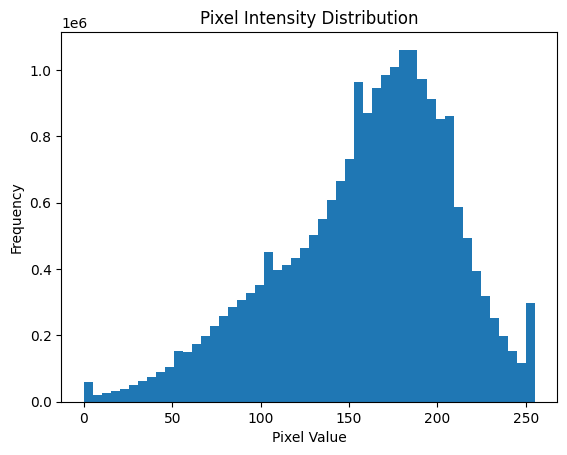

In [8]:
# -----------------------------
# 5. Pixel Intensity Analysis
# -----------------------------
pixels = X_train.values.flatten()

print("\nPixel Intensity Statistics:")
print("Mean:", np.mean(pixels))
print("Std Dev:", np.std(pixels))
print("Min:", np.min(pixels))
print("Max:", np.max(pixels))

plt.figure()
plt.hist(pixels, bins=50)
plt.title("Pixel Intensity Distribution")
plt.xlabel("Pixel Value")
plt.ylabel("Frequency")
plt.show()

This plot illustrates the distribution of grayscale pixel intensities across the ASL-MNIST training dataset. Pixel values range from 0 (black) to 255 (white), representing different brightness levels within the images.

The histogram indicates that most pixel values are concentrated between approximately 100 and 200, with a peak around 160–180. This suggests that a large portion of the image content corresponds to mid-to-high intensity values, which primarily represent the hand regions. Lower pixel values correspond to darker background areas.

Very few pixels are observed at extreme intensity levels, indicating the absence of overexposed or underexposed images. The smooth distribution demonstrates consistent lighting conditions and good dataset quality.

This analysis confirms sufficient contrast between foreground and background regions, which is beneficial for feature extraction. Furthermore, it justifies the application of pixel normalization prior to model training to improve numerical stability and learning efficiency.

In [9]:
# -----------------------------
# 6. Image Dimension Verification
# -----------------------------
image_shape = X_train.iloc[0].values.reshape(28, 28).shape
print("\nImage Shape:", image_shape)



Image Shape: (28, 28)


To confirm the consistency of image dimensions within the dataset, a sample image was reshaped from its flattened representation into a two-dimensional format. The resulting shape was verified as 28 × 28 pixels.

This verification step ensures that all images conform to the expected input size required for convolutional neural networks. Uniform image dimensions are essential for batch processing and model training, as inconsistent shapes can lead to computational errors and degraded performance.

The confirmed image size aligns with the ASL-MNIST dataset specifications and supports the suitability of the dataset for CNN-based gesture recognition.

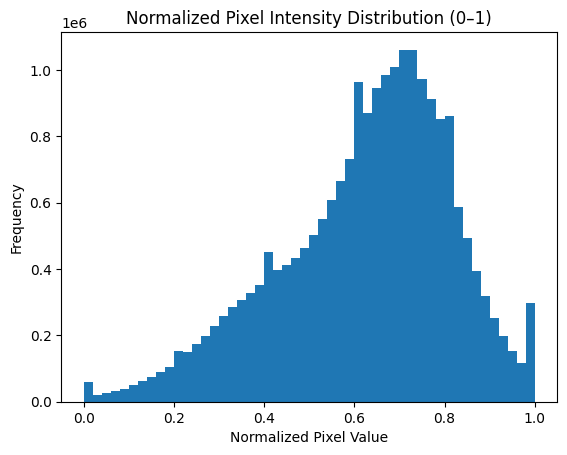

In [10]:
# -----------------------------
# 7. Normalization Analysis
# -----------------------------
X_train_normalized = X_train / 255.0

norm_pixels = X_train_normalized.values.flatten()

plt.figure()
plt.hist(norm_pixels, bins=50)
plt.title("Normalized Pixel Intensity Distribution (0–1)")
plt.xlabel("Normalized Pixel Value")
plt.ylabel("Frequency")
plt.show()

This figure presents the histogram of pixel intensities after normalization to the range [0, 1]. Normalization was performed by dividing each pixel value by 255, converting grayscale intensities into floating-point values suitable for deep learning models.

The normalized histogram retains the original distribution pattern, with most pixel values concentrated between approximately 0.6 and 0.8, corresponding primarily to hand regions. Lower values represent darker background areas.

The preservation of distribution shape indicates that normalization does not alter the intrinsic characteristics of the images but instead rescales them to improve numerical stability. This preprocessing step facilitates faster convergence during training and reduces the risk of gradient-related issues.

Overall, normalized pixel values provide a consistent input scale, enhancing model performance and learning efficiency.

In [11]:
# -----------------------------
# 8. Class-wise Statistical Summary
# -----------------------------
class_summary = train_df.groupby('label').agg(['mean', 'std'])
print("\nClass-wise Statistical Summary:")
print(class_summary)



Class-wise Statistical Summary:
           pixel1                 pixel2                 pixel3             \
             mean        std        mean        std        mean        std   
label                                                                        
0      164.192718  35.654405  165.654529  36.533511  162.869449  45.609841   
1      145.215842  41.161590  147.747525  40.744613  150.145545  39.553499   
2      160.759615  38.059112  163.133741  35.374370  165.435315  32.535158   
3      135.755853  41.465282  139.376254  41.406190  143.024247  41.718486   
4      165.823406  33.563017  167.623824  32.566099  169.475444  31.702373   
5      142.225914  36.677251  146.210963  35.101497  149.949336  33.755710   
6      172.902752  28.232728  174.281651  27.972710  175.629358  27.603686   
7      164.142152  33.420567  166.440276  32.060769  168.638697  31.029945   
8      158.496558  34.650295  160.747849  33.044056  163.317556  31.011595   
10      98.201077  39.890584  1

The class-wise statistical analysis confirms distinct pixel intensity patterns across gestures and demonstrates adequate variability without excessive noise, providing a reliable foundation for deep learning model training.

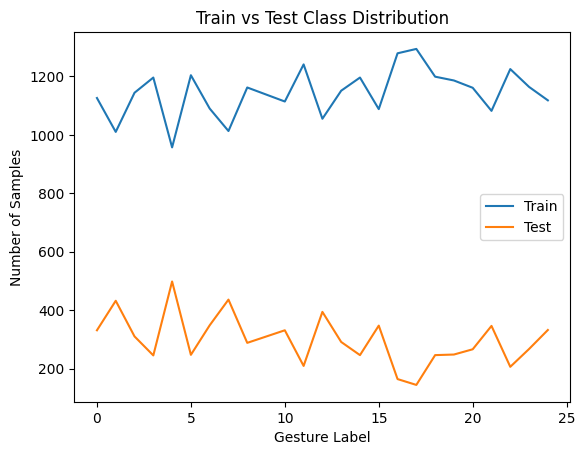

In [12]:
# -----------------------------
# 9. Train vs Test Distribution Comparison
# -----------------------------
train_counts = train_df['label'].value_counts().sort_index()
test_counts = test_df['label'].value_counts().sort_index()

plt.figure()
plt.plot(train_counts.index, train_counts.values, label='Train')
plt.plot(test_counts.index, test_counts.values, label='Test')
plt.title("Train vs Test Class Distribution")
plt.xlabel("Gesture Label")
plt.ylabel("Number of Samples")
plt.legend()
plt.show()

The plot shows that the training dataset contains substantially more samples per class compared to the testing dataset, which is expected due to the predefined dataset split. On average, each class in the training set contains approximately 1,000–1,300 samples, while the testing set contains roughly 150–500 samples per class.

Both curves follow a similar pattern across gesture labels, indicating that the relative distribution of samples is consistent between the training and testing sets. This alignment suggests that no significant class bias exists between the two subsets, ensuring that the test data is representative of the training data.

Although minor fluctuations in sample counts can be observed across certain gesture classes, these variations are not severe and do not indicate extreme class imbalance. Such consistency is important for reliable model evaluation, as it minimizes dataset shift and allows performance metrics obtained on the test set to accurately reflect real-world generalization.

In [13]:
le = LabelEncoder()

y_train = le.fit_transform(y_train)
y_test = le.transform(y_test)

In [14]:
X_train = X_train.values.reshape(-1,28,28,1)/255.0
X_test = X_test.values.reshape(-1,28,28,1)/255.0


In [15]:
y_train = to_categorical(y_train)
y_test = to_categorical(y_test)



The labels were first converted into numerical format using LabelEncoder to make them compatible with machine learning algorithms. The images were reshaped into 28×28 grayscale format to match CNN input requirements. Pixel normalization was applied to scale values between 0 and 1 to improve convergence. Finally, one-hot encoding was used to convert class labels into categorical vectors suitable for softmax classification. If you do not one-hot encode:
    Shape mismatch error
    Incorrect loss calculation

In [16]:
batch_sizes = [32, 64]
epochs_list = [10, 15]
dropouts = [0.3, 0.5]

def create_model(dropout_rate):

    model = Sequential([
        Conv2D(32,(3,3),activation='relu',input_shape=(28,28,1)),
        MaxPooling2D(),

        Conv2D(64,(3,3),activation='relu'),
        MaxPooling2D(),

        Flatten(),
        Dense(128,activation='relu'),
        Dropout(dropout_rate),

        Dense(24,activation='softmax')
    ])

    model.compile(
        optimizer="adam",
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model



Convolutional Neural Network (CNN) built using a Sequential architecture, where layers are stacked one after another. It begins with two convolutional layers (32 and 64 filters of size 3×3) with ReLU activation to automatically extract important visual features from 28×28 grayscale hand gesture images. Each convolution layer is followed by MaxPooling to reduce spatial dimensions and computational complexity while retaining key features. The extracted feature maps are then flattened into a one-dimensional vector and passed to a fully connected Dense layer with 128 neurons to learn high-level patterns. A Dropout layer (50%) is used to prevent overfitting by randomly disabling neurons during training. Finally, a Dense output layer with 24 neurons and softmax activation produces probability scores for each ASL alphabet class, enabling multi-class gesture classification.

The model has 226,840 total trainable parameters, meaning all weights are updated during training. Most parameters (204,928) are in the fully connected Dense layer, which typically contains the largest number of learnable weights. There are no non-trainable parameters, indicating the entire network participates in learning.

Overall, this is a well-structured CNN suitable for ASL gesture classification.

In [17]:
results = []

for batch in batch_sizes:
    for epochs in epochs_list:
        for dropout in dropouts:

            print(f"Training with batch={batch}, epochs={epochs}, dropout={dropout}")

            model = create_model(dropout)

            history = model.fit(
                X_train,
                y_train,
                epochs=epochs,
                batch_size=batch,
                validation_split=0.1,
                verbose=0
            )

            loss, acc = model.evaluate(X_test, y_test, verbose=0)

            results.append((batch, epochs, dropout, acc))



Training with batch=32, epochs=10, dropout=0.3


C:\Users\raviv\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Training with batch=32, epochs=10, dropout=0.5
Training with batch=32, epochs=15, dropout=0.3
Training with batch=32, epochs=15, dropout=0.5
Training with batch=64, epochs=10, dropout=0.3
Training with batch=64, epochs=10, dropout=0.5
Training with batch=64, epochs=15, dropout=0.3
Training with batch=64, epochs=15, dropout=0.5


In [18]:
for r in results:
    print("Batch:", r[0],
          "Epochs:", r[1],
          "Dropout:", r[2],
          "Accuracy:", r[3])

Batch: 32 Epochs: 10 Dropout: 0.3 Accuracy: 0.9245677590370178
Batch: 32 Epochs: 10 Dropout: 0.5 Accuracy: 0.9308421611785889
Batch: 32 Epochs: 15 Dropout: 0.3 Accuracy: 0.940044641494751
Batch: 32 Epochs: 15 Dropout: 0.5 Accuracy: 0.9474344849586487
Batch: 64 Epochs: 10 Dropout: 0.3 Accuracy: 0.9287506937980652
Batch: 64 Epochs: 10 Dropout: 0.5 Accuracy: 0.9312604665756226
Batch: 64 Epochs: 15 Dropout: 0.3 Accuracy: 0.9344673752784729
Batch: 64 Epochs: 15 Dropout: 0.5 Accuracy: 0.9177356362342834


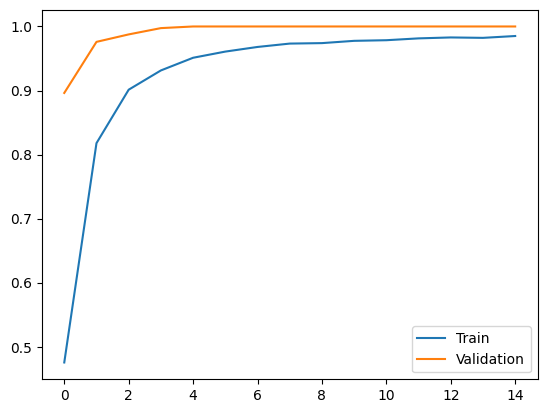

In [19]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.legend(["Train","Validation"])
plt.show()


In [20]:
loss,acc = model.evaluate(X_test,y_test)
print("Test Accuracy:",acc)


225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9177 - loss: 0.3458
Test Accuracy: 0.9177356362342834


Since both training and validation accuracy increase together and remain close to each other, there is no significant overfitting. The model generalizes well to new data. By the final epoch, training accuracy is around 97–98% and validation accuracy is nearly 100%, showing that the model has learned the ASL gesture patterns effectively.

Overall, the graph suggests that  CNN is well-trained and performs very well on both training and validation datasets.

225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step


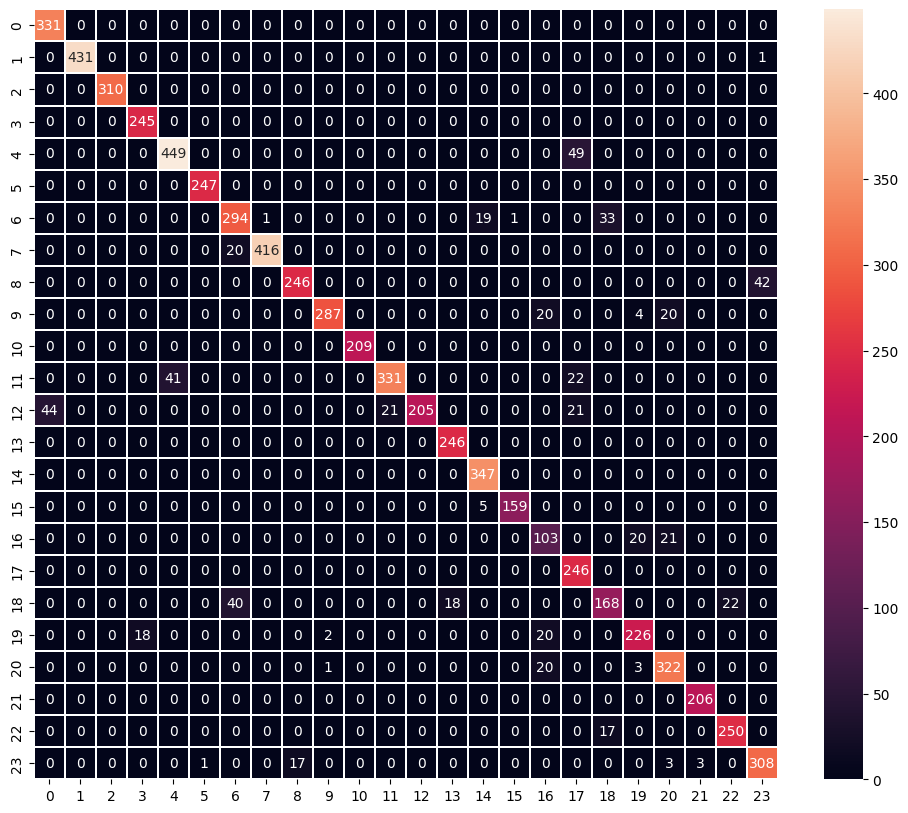

In [21]:
y_pred = np.argmax(model.predict(X_test),axis=1)
y_true = np.argmax(y_test,axis=1)

cm = confusion_matrix(y_true,y_pred)
plt.figure(figsize=(12,10))
sns.heatmap(cm,annot=True,fmt="d",linewidth=0.1)
plt.show()


In [22]:
print(classification_report(y_true,y_pred))


              precision    recall  f1-score   support

           0       0.88      1.00      0.94       331
           1       1.00      1.00      1.00       432
           2       1.00      1.00      1.00       310
           3       0.93      1.00      0.96       245
           4       0.92      0.90      0.91       498
           5       1.00      1.00      1.00       247
           6       0.83      0.84      0.84       348
           7       1.00      0.95      0.98       436
           8       0.94      0.85      0.89       288
           9       0.99      0.87      0.92       331
          10       1.00      1.00      1.00       209
          11       0.94      0.84      0.89       394
          12       1.00      0.70      0.83       291
          13       0.93      1.00      0.96       246
          14       0.94      1.00      0.97       347
          15       0.99      0.97      0.98       164
          16       0.63      0.72      0.67       144
          17       0.73    

Predicted Letter: G
Current Word: G


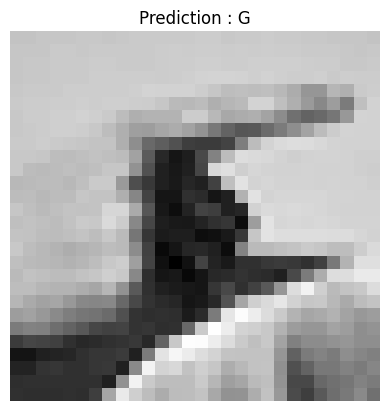

Predicted Letter: F
Current Word: GF


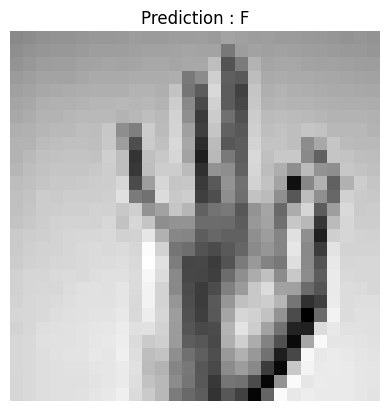

Predicted Letter: K
Current Word: GFK


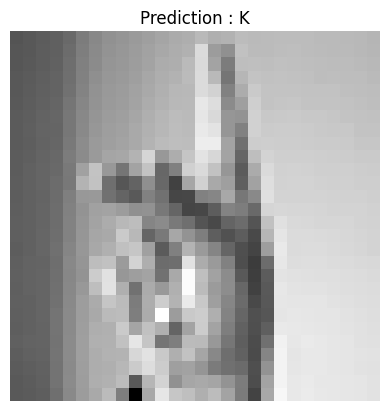

Predicted Letter: A
Current Word: GFKA


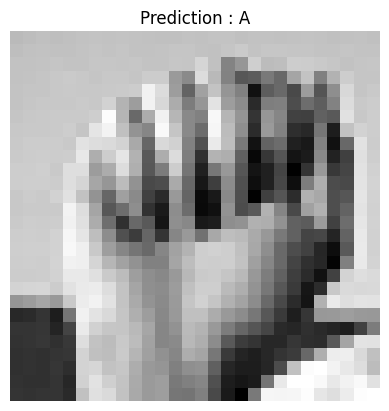

Predicted Letter: D
Current Word: GFKAD


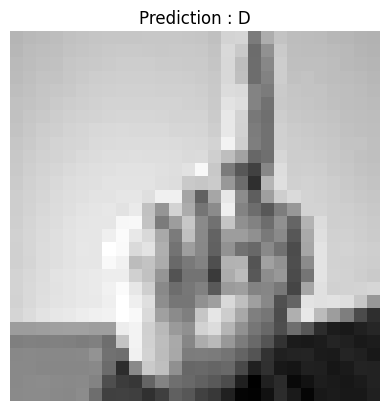

Predicted Letter: V
Current Word: GFKADV


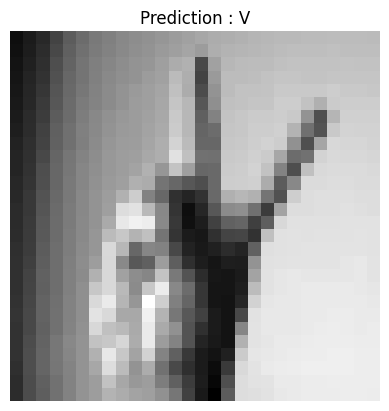

Predicted Letter: K
Current Word: GFKADVK


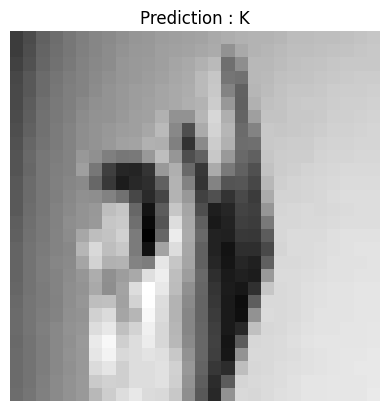

Predicted Letter: O
Current Word: GFKADVKO


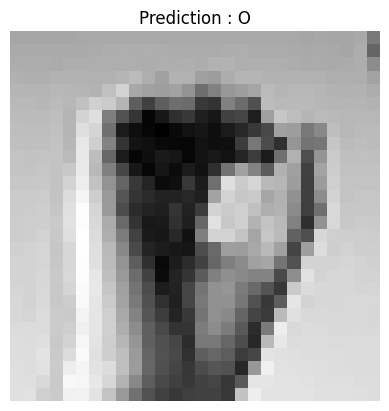

Predicted Letter: D
Current Word: GFKADVKOD


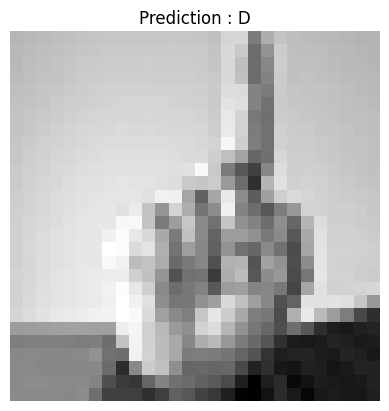

Predicted Letter: H
Current Word: GFKADVKODH


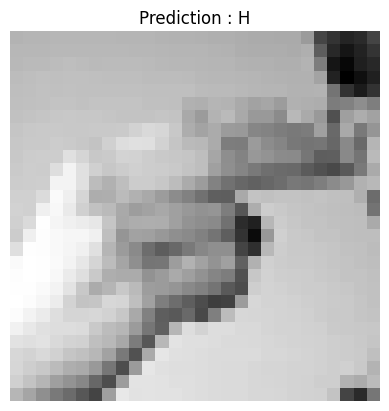

In [23]:

# Letter Mapping

letters = list(string.ascii_uppercase)

# Remove motion letters
letters.remove('J')
letters.remove('Z')


#  Word Builder

current_word = ""
last_letter = None

def update_word(letter):
    global current_word,last_letter

    if letter != last_letter:
        current_word += letter
        last_letter = letter

    print("Predicted Letter:",letter)
    print("Current Word:",current_word)


#  Prediction Function

def predict_letter(image):

    img = image.reshape(1,28,28,1)
    prediction = model.predict(img,verbose=0)

    class_index = np.argmax(prediction)
    letter = letters[class_index]

    return letter


#  Show Image + Prediction

for i in range(10):

    image = X_test[i]

    letter = predict_letter(image)

    update_word(letter)

    plt.imshow(image.reshape(28,28),cmap='gray')
    plt.title(f"Prediction : {letter}")
    plt.axis("off")
    plt.show()



In [25]:
# Optional Speech (Assistive Feature)

try:
    import pyttsx3

    engine = pyttsx3.init()

    def speak():
        engine.say(current_word)
        engine.runAndWait()

    speak()
    print("Spoken Word:", current_word)

except:
    print("Speech module not installed")

Spoken Word: GFKADVKODH
